# duckdb-cog — SQL over Cloud-Optimized GeoTIFFs

**[duckdb-cog](https://github.com/st-layer/duckdb-cog)** exposes Cloud-Optimized GeoTIFF rasters as SQL tables — *in place*, over
HTTP/S3 range reads. No download, no re-encoding, no reprojection, and no GDAL in the read path.

This notebook tours four use cases against **live public Sentinel-2 data**:

1. **Explore a remote COG** without downloading it (metadata-only range reads)
2. **Pixel values & zonal statistics** straight off the object store
3. **Search a live STAC catalog** with one table function
4. **A field-boundary reflectance time series in a single SQL query** (with DuckDB `spatial` for reprojection)

Requirements: `duckdb` (Python) ≥ 1.5.4, network access. Every pixel-facing result of this
extension is cross-checked against a rasterio oracle in CI.

In [1]:
import os
import duckdb

# Anonymous access to public S3 buckets (e.g. the Sentinel-2 open-data bucket).
# Must be set before the first remote query — see the README "Remote sources" section.
os.environ["AWS_SKIP_SIGNATURE"] = "true"

con = duckdb.connect(config={"allow_unsigned_extensions": True})
try:
    con.execute("INSTALL cog FROM community; LOAD cog;")
except duckdb.Error:
    # Fallback for a development checkout (community registration pending)
    con.execute("LOAD '../build/release/cog.duckdb_extension'")
con.execute("INSTALL spatial; LOAD spatial;")   # used in use case 4

con.execute("SELECT * FROM cog_version()").df()

,version
0,duckdb-cog 0.1.0


## 1. Explore a remote COG — without downloading it

`read_cog()` lists the tile grid of a 120 MB Sentinel-2 band with a couple of
small HTTP range reads. The pixels are never touched — that lazy-IO property is
pinned by a test that counts every byte the reader fetches.

In [2]:
B04 = "https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/52/S/CG/2026/6/S2B_52SCG_20260630_0_L2A/B04.tif"

con.execute(f"""
    SELECT level,
           count(*)            AS tiles,
           min(bbox.xmin)      AS xmin,
           max(bbox.ymax)      AS ymax,
           any_value(crs)      AS crs
    FROM read_cog('{B04}')
    GROUP BY level ORDER BY level
""").df()

,level,tiles,xmin,ymax,crs
0,0,121,300000.0,4200000.0,EPSG:32652
1,1,121,300000.0,4200000.0,EPSG:32652
2,2,36,300000.0,4200000.0,EPSG:32652
3,3,9,300000.0,4200000.0,EPSG:32652
4,4,4,300000.0,4200000.0,EPSG:32652


In [3]:
con.execute(f"""
    SELECT RS_Width(f) AS width, RS_Height(f) AS height,
           RS_NumBands(f) AS bands, RS_SRID(f) AS srid,
           RS_ScaleX(f) AS pixel_size_m
    FROM (SELECT '{B04}' AS f)
""").df()

,width,height,bands,srid,pixel_size_m
0,10980,10980,1,32652,10.0


## 2. Pixel values & zonal statistics

Coordinates are in the raster's **native CRS** (here UTM 52N / EPSG:32652) —
values are read as stored, with no resampling or interpolation. `RS_ZonalStats`
fetches only the tiles its bounding box touches, decodes each once, and
aggregates the pixels whose centers fall inside.

In [4]:
con.execute(f"""
    SELECT RS_Value('{B04}', 325210.0, 4121100.0)                                    AS red_at_point,
           RS_ZonalStats('{B04}', [322000.0, 4119000.0, 326400.0, 4123200.0], 1, 'count') AS px_count,
           round(RS_ZonalStats('{B04}', [322000.0, 4119000.0, 326400.0, 4123200.0], 1, 'mean'), 1) AS zonal_mean
""").df()

,red_at_point,px_count,zonal_mean
0,1748.0,184800.0,1916.4


## 3. Search a live STAC catalog

`read_stac_search()` drives a STAC API's `POST /search` — body filters, `rel=next`
pagination and all — and returns one row per *(item, asset)*. The search `bbox`
is WGS84 lon/lat (that's the STAC standard), and `datetime` must be RFC3339.

In [5]:
scenes = con.execute("""
    SELECT item_id, datetime, href
    FROM read_stac_search('https://earth-search.aws.element84.com/v1/search',
                          collections := ['sentinel-2-l2a'],
                          bbox := [127.01, 37.20, 127.06, 37.24],
                          datetime := '2026-06-01T00:00:00Z/2026-07-13T00:00:00Z')
    WHERE asset_key = 'red'
    ORDER BY datetime
""").df()
scenes

,item_id,datetime,href
0,S2C_52SCG_20260605_0_L2A,2026-06-05T02:27:11.287000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
1,S2A_52SCG_20260607_0_L2A,2026-06-07T02:27:28.239000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
2,S2B_52SCG_20260610_0_L2A,2026-06-10T02:27:10.309000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
3,S2C_52SCG_20260615_0_L2A,2026-06-15T02:27:12.397000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
4,S2B_52SCG_20260620_0_L2A,2026-06-20T02:27:10.999000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
5,S2C_52SCG_20260625_0_L2A,2026-06-25T02:27:11.971000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
6,S2B_52SCG_20260630_0_L2A,2026-06-30T02:27:10.131000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
7,S2C_52SCG_20260705_0_L2A,2026-07-05T02:27:11.817000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
8,S2B_52SCG_20260710_0_L2A,2026-07-10T02:27:11.490000Z,https://sentinel-cogs.s3.us-west-2.amazonaws.c...


## 4. Field-boundary time series — one SQL query

The real-world ask: *"given a field boundary as ordinary lon/lat GeoJSON, give me
the mean red reflectance over time."* Two coordinate systems are in play:

- the **STAC search bbox** is WGS84 (standard),
- but **`RS_ZonalStats` coordinates are native CRS** — feeding it lon/lat silently
  yields an empty aggregate (no error!).

DuckDB's `spatial` extension bridges the two entirely in SQL: `RS_SRID(href)`
supplies each scene's CRS to `ST_Transform` (note **`always_xy := true`** —
without it EPSG:4326 is interpreted lat-first and you get `POINT (inf inf)`).
The polygon is approximated by its bounding box (pixel-exact polygon clipping
would need GEOS, which is deliberately outside this extension's scope).

In [6]:
GEOJSON = '{"type":"Polygon","coordinates":[[[127.02,37.20],[127.05,37.21],[127.06,37.23],[127.03,37.24],[127.01,37.22],[127.02,37.20]]]}'

ts = con.execute(f"""
    WITH scenes AS (
        SELECT datetime, href
        FROM read_stac_search('https://earth-search.aws.element84.com/v1/search',
                              collections := ['sentinel-2-l2a'],
                              bbox := [127.01, 37.20, 127.06, 37.24],
                              datetime := '2026-06-01T00:00:00Z/2026-07-13T00:00:00Z')
        WHERE asset_key = 'red'
    ),
    zoned AS (   -- reproject the GeoJSON into each scene's native CRS, in SQL
        SELECT datetime, href,
               ST_Transform(ST_GeomFromGeoJSON('{GEOJSON}'),
                            'EPSG:4326', 'EPSG:' || RS_SRID(href),
                            always_xy := true) AS g
        FROM scenes
    )
    SELECT CAST(datetime[:10] AS DATE) AS date,
           round(RS_ZonalStats(href, [ST_XMin(g), ST_YMin(g), ST_XMax(g), ST_YMax(g)], 1, 'mean'), 1) AS mean_red
    FROM zoned
    ORDER BY date
""").df()
ts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,date,mean_red
0,2026-06-05,1935.5
1,2026-06-07,9876.4
2,2026-06-10,3369.7
3,2026-06-15,1265.5
4,2026-06-20,9891.5
5,2026-06-25,7475.7
6,2026-06-30,1888.1
7,2026-07-05,8049.5
8,2026-07-10,10264.0


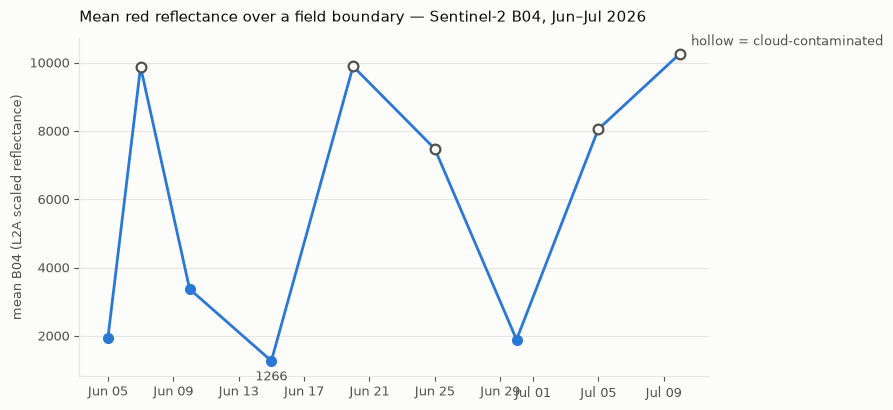

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SERIES, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e5e5e2"
CLOUD_THRESHOLD = 5000        # L2A red reflectance this high over farmland = clouds

fig, ax = plt.subplots(figsize=(9, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.plot(ts["date"], ts["mean_red"], color=SERIES, linewidth=2, zorder=2)
clear  = ts[ts["mean_red"] <= CLOUD_THRESHOLD]
cloudy = ts[ts["mean_red"] >  CLOUD_THRESHOLD]
ax.plot(clear["date"],  clear["mean_red"],  "o", color=SERIES, markersize=7, zorder=3)
ax.plot(cloudy["date"], cloudy["mean_red"], "o", markerfacecolor="#fcfcfb",
        markeredgecolor=MUTED, markeredgewidth=1.6, markersize=7, zorder=3)

if len(cloudy):
    top = cloudy.loc[cloudy["mean_red"].idxmax()]
    ax.annotate("hollow = cloud-contaminated", xy=(top["date"], top["mean_red"]),
                xytext=(8, 6), textcoords="offset points", color=MUTED, fontsize=9)
if len(clear):
    low = clear.loc[clear["mean_red"].idxmin()]
    ax.annotate(f'{low["mean_red"]:.0f}', xy=(low["date"], low["mean_red"]),
                xytext=(0, -14), textcoords="offset points",
                ha="center", color=MUTED, fontsize=9)

ax.set_title("Mean red reflectance over a field boundary — Sentinel-2 B04, Jun–Jul 2026",
             color=INK, fontsize=11, loc="left", pad=12)
ax.set_ylabel("mean B04 (L2A scaled reflectance)", color=MUTED, fontsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=1)
ax.tick_params(colors=MUTED, labelsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
plt.tight_layout()
plt.show()

## 5. Cloud masking with the SCL band

Sentinel-2 L2A ships a **Scene Classification Layer** (`scl` asset, 20 m): each
pixel is labeled vegetation / water / cloud / shadow / etc. Cloud classes are
`3` (shadow), `8`/`9` (cloud medium/high probability) and `10` (thin cirrus).

Below, both bands are fetched **through SQL** (`RS_BandAsArray` — still no scene
download), then numpy aligns the 20 m mask onto the 10 m band (each SCL pixel
covers a 2×2 block) and recomputes the mean over clear pixels only.

In [8]:
import numpy as np

# B04(red, 10 m) + SCL(20 m) href 를 씬별로 짝지어 가져온다
pairs = con.execute("""
    SELECT CAST(datetime[:10] AS DATE) AS date,
           max(CASE WHEN asset_key = 'red' THEN href END) AS b04,
           max(CASE WHEN asset_key = 'scl' THEN href END) AS scl
    FROM read_stac_search('https://earth-search.aws.element84.com/v1/search',
                          collections := ['sentinel-2-l2a'],
                          bbox := [127.01, 37.20, 127.06, 37.24],
                          datetime := '2026-06-01T00:00:00Z/2026-07-13T00:00:00Z')
    WHERE asset_key IN ('red', 'scl') AND item_id LIKE '%_52SCG_%'
    GROUP BY date ORDER BY date
""").df()

BBOX = "[322000.0, 4119000.0, 326400.0, 4123200.0]"   # 4.4 x 4.2 km, EPSG:32652
CLOUD = (3, 8, 9, 10)

records = []
for _, r in pairs.iterrows():
    # NULL(nodata) 원소는 dtype=float 로 받으면 NaN 이 된다
    B = np.array(con.execute(f"SELECT RS_BandAsArray('{r.b04}', 1, {BBOX})").fetchone()[0],
                 dtype=float).reshape(420, 440)          # 10 m
    S = np.array(con.execute(f"SELECT RS_BandAsArray('{r.scl}', 1, {BBOX})").fetchone()[0],
                 dtype=float).reshape(210, 220)          # 20 m
    cloud = np.isin(np.repeat(np.repeat(S, 2, 0), 2, 1), CLOUD)   # 20 m -> 10 m
    masked = np.where(cloud, np.nan, B)
    # 유효(맑은) 픽셀이 5% 미만이면 추정 불가로 처리 — 구름 가장자리
    # 찌꺼기 몇 픽셀이 평균을 지배하는 것을 막는다 (표준 관행)
    enough_clear = np.isfinite(masked).sum() >= 0.05 * masked.size
    records.append(dict(date=r.date, cloud_pct=round(cloud.mean() * 100, 1),
                        raw_mean=round(np.nanmean(B), 1),
                        masked_mean=(round(np.nanmean(masked), 1)
                                     if enough_clear else None)))
import pandas as pd
cm = pd.DataFrame(records)
cm

,date,cloud_pct,raw_mean,masked_mean
0,2026-06-05,37.0,1469.0,1253.4
1,2026-06-07,100.0,9755.3,NaN
2,2026-06-10,57.1,2787.9,1334.5
3,2026-06-15,0.0,1223.0,1223.0
4,2026-06-20,99.9,9828.0,NaN
5,2026-06-25,100.0,7625.0,NaN
6,2026-06-30,100.0,1916.4,NaN
7,2026-07-05,100.0,8527.8,NaN
8,2026-07-10,100.0,10298.4,NaN


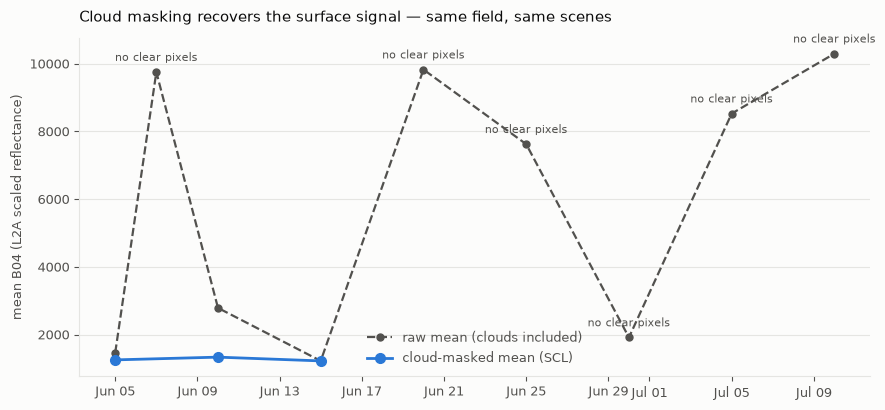

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.plot(cm["date"], cm["raw_mean"], color=MUTED, linewidth=1.6,
        linestyle="--", marker="o", markersize=5, label="raw mean (clouds included)")
ok = cm[cm["masked_mean"].notna()]
ax.plot(ok["date"], ok["masked_mean"], color=SERIES, linewidth=2,
        marker="o", markersize=7, label="cloud-masked mean (SCL)")

for _, r in cm[cm["masked_mean"].isna()].iterrows():
    ax.annotate("no clear pixels", xy=(r["date"], r["raw_mean"]), xytext=(0, 8),
                textcoords="offset points", ha="center", color=MUTED, fontsize=8)

ax.set_title("Cloud masking recovers the surface signal — same field, same scenes",
             color=INK, fontsize=11, loc="left", pad=12)
ax.set_ylabel("mean B04 (L2A scaled reflectance)", color=MUTED, fontsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=1)
ax.tick_params(colors=MUTED, labelsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
ax.legend(frameon=False, fontsize=9, labelcolor=MUTED)
plt.tight_layout()
plt.show()

The pattern is the Korean monsoon in data: low values are clear-sky vegetation
(red absorbed by chlorophyll), the hollow spikes are clouds. Filter them out and
this is an NDVI-ready ingredient — computed **without downloading a single scene**.

## Notes & footguns

| topic | the rule |
| -- | -- |
| Anonymous public S3 | set `AWS_SKIP_SIGNATURE=true` *before* the first query, or the client hangs probing EC2 metadata |
| STAC `datetime` | must be RFC3339 (`2026-06-01T00:00:00Z/...`) — date-only intervals are rejected by Earth Search |
| `RS_*` coordinates | native CRS, never lon/lat — reproject first (empty results, not errors, if you forget) |
| `ST_Transform` | pass `always_xy := true` for EPSG:4326 input, or coordinates come out `inf` |
| Polygons | approximated by their bbox — pixel-exact clipping is out of scope by design (no GEOS) |
| Repeat access | remote metadata is cached process-wide for 60 s (`COG_REMOTE_CACHE_TTL_S` to tune/disable) |

More: [README](https://github.com/st-layer/duckdb-cog#readme) ·
[benchmarks](https://github.com/st-layer/duckdb-cog/tree/main/docs/benchmarks) —
zonal mean 2.9 ms local, cold remote metadata 0.84 s, warm repeat 0.4 ms.